In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# 设置随机种子（保证结果可复现）
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# 检查设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ 所有库导入成功")
print(f"   PyTorch 版本：{torch.__version__}")
print(f"   使用设备：{device}")
print(f"   随机种子：{SEED}")

✅ 所有库导入成功
   PyTorch 版本：2.13.0+cpu
   使用设备：cpu
   随机种子：42


In [4]:
# 加载特征矩阵
df = pd.read_csv("../data/processed/plaid_rotor37_features.csv")

print(f"✅ 特征矩阵加载成功")
print(f"   形状：{df.shape}")
print(f"   列名（前5个）：{list(df.columns[:5])}")

# 定义输入和输出列
input_cols = [c for c in df.columns 
              if c not in ['sample_id', 'Compression_ratio', 
                           'Efficiency', 'Massflow']]
output_cols = ['Compression_ratio', 'Efficiency', 'Massflow']

print(f"\n输入特征数：{len(input_cols)}")
print(f"输出标签数：{len(output_cols)}")
print(f"输出列名：{output_cols}")

# 提取 X 和 y
X_raw = df[input_cols].values.astype(np.float32)
y_raw = df[output_cols].values.astype(np.float32)

print(f"\nX shape：{X_raw.shape}")
print(f"y shape：{y_raw.shape}")

✅ 特征矩阵加载成功
   形状：(1000, 78)
   列名（前5个）：['sample_id', 'Omega', 'P', 'CoordinateX_mean', 'CoordinateX_std']

输入特征数：74
输出标签数：3
输出列名：['Compression_ratio', 'Efficiency', 'Massflow']

X shape：(1000, 74)
y shape：(1000, 3)


In [5]:
# 第一刀：切出测试集（10%，100个样本）
X_temp, X_test, y_temp, y_test = train_test_split(
    X_raw, y_raw, 
    test_size=0.10, 
    random_state=SEED
)

# 第二刀：从剩余90%里切出验证集（约11%，共100个样本）
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.111, 
    random_state=SEED
)

print("✅ 数据集划分完成")
print(f"   训练集：{X_train.shape[0]} 个样本")
print(f"   验证集：{X_val.shape[0]} 个样本")
print(f"   测试集：{X_test.shape[0]} 个样本")
print(f"   合计：  {X_train.shape[0]+X_val.shape[0]+X_test.shape[0]} 个样本")

# 验证划分比例
total = len(df)
print(f"\n实际比例：")
print(f"   训练：{X_train.shape[0]/total*100:.1f}%")
print(f"   验证：{X_val.shape[0]/total*100:.1f}%")
print(f"   测试：{X_test.shape[0]/total*100:.1f}%")

✅ 数据集划分完成
   训练集：800 个样本
   验证集：100 个样本
   测试集：100 个样本
   合计：  1000 个样本

实际比例：
   训练：80.0%
   验证：10.0%
   测试：10.0%


In [6]:
# ── 为什么要标准化？ ──────────────────────────────────────
# 不同特征的数值量级差异极大：
#   Omega ≈ 1600~1800（rpm）
#   Pressure_mean ≈ 100,000（Pa）
#   CoordinateX ≈ 0.001~0.05（m）
# 如果不标准化，神经网络会被大数值的特征"淹没"
# 标准化后全部变成均值0、标准差1的分布

# 输入标准化
scaler_X = StandardScaler()
X_train_sc = scaler_X.fit_transform(X_train)   # 在训练集上 fit
X_val_sc   = scaler_X.transform(X_val)         # 验证集和测试集只 transform
X_test_sc  = scaler_X.transform(X_test)

# 输出标准化
scaler_y = StandardScaler()
y_train_sc = scaler_y.fit_transform(y_train)
y_val_sc   = scaler_y.transform(y_val)
y_test_sc  = scaler_y.transform(y_test)

print("✅ 标准化完成")
print(f"\n标准化前 X_train：")
print(f"   均值范围：[{X_train.mean(axis=0).min():.2f}, {X_train.mean(axis=0).max():.2f}]")
print(f"   标准差范围：[{X_train.std(axis=0).min():.4f}, {X_train.std(axis=0).max():.2f}]")

print(f"\n标准化后 X_train_sc：")
print(f"   均值范围：[{X_train_sc.mean(axis=0).min():.4f}, {X_train_sc.mean(axis=0).max():.4f}]")
print(f"   标准差范围：[{X_train_sc.std(axis=0).min():.4f}, {X_train_sc.std(axis=0).max():.4f}]")

# 保存两个 Scaler
os.makedirs("../models", exist_ok=True)
joblib.dump(scaler_X, "../models/scaler_X.pkl")
joblib.dump(scaler_y, "../models/scaler_y.pkl")
print(f"\n✅ Scaler 已保存到 models/")

✅ 标准化完成

标准化前 X_train：
   均值范围：[-1.63, 367647.09]
   标准差范围：[0.0000, 12454.87]

标准化后 X_train_sc：
   均值范围：[-0.0000, 0.0000]
   标准差范围：[1.0000, 1.0000]

✅ Scaler 已保存到 models/


In [7]:
# ── 什么是 Dataset 和 DataLoader？ ───────────────────────
# Dataset：告诉 PyTorch "我的数据长什么样"
# DataLoader：把数据切成一批一批（batch）喂给神经网络
#             每次训练不是一次性用所有数据，而是每次用32个样本

class TurbineDataset(Dataset):
    """
    叶轮机械气动性能数据集
    输入：74维特征向量（标准化后）
    输出：3维性能标签（压比、效率、质量流量，标准化后）
    """
    def __init__(self, X, y):
        # 转成 PyTorch 张量（tensor）
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        # 告诉 PyTorch 数据集有多少个样本
        return len(self.X)
    
    def __getitem__(self, idx):
        # 告诉 PyTorch 怎么取第 idx 个样本
        return self.X[idx], self.y[idx]


# 创建三个数据集
train_dataset = TurbineDataset(X_train_sc, y_train_sc)
val_dataset   = TurbineDataset(X_val_sc,   y_val_sc)
test_dataset  = TurbineDataset(X_test_sc,  y_test_sc)

# 创建三个 DataLoader
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, 
                          shuffle=True,  drop_last=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, 
                          shuffle=False, drop_last=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, 
                          shuffle=False, drop_last=False)

print("✅ Dataset 和 DataLoader 创建成功")
print(f"\n训练集 DataLoader：")
print(f"   样本数：{len(train_dataset)}")
print(f"   Batch大小：{BATCH_SIZE}")
print(f"   Batch数量：{len(train_loader)}")

# 取一个 batch 验证形状
X_batch, y_batch = next(iter(train_loader))
print(f"\n一个 Batch 的形状：")
print(f"   X_batch：{X_batch.shape}  → (batch_size=32, features=74)")
print(f"   y_batch：{y_batch.shape}  → (batch_size=32, outputs=3)")

✅ Dataset 和 DataLoader 创建成功

训练集 DataLoader：
   样本数：800
   Batch大小：32
   Batch数量：25

一个 Batch 的形状：
   X_batch：torch.Size([32, 74])  → (batch_size=32, features=74)
   y_batch：torch.Size([32, 3])  → (batch_size=32, outputs=3)


In [8]:
class BaselineMLP(nn.Module):
    """
    基线多层感知机（MLP）代理模型
    
    架构：
    输入(74) → Linear(256) → BN → ReLU → Dropout
             → Linear(256) → BN → ReLU → Dropout
             → Linear(128) → BN → ReLU → Dropout
             → Linear(64)  → BN → ReLU
             → 输出(3)
    
    BN = Batch Normalization（批归一化，让训练更稳定）
    Dropout = 随机丢弃神经元（防止过拟合）
    """
    def __init__(self, input_dim=74, output_dim=3, 
                 hidden_dims=[256, 256, 128, 64], dropout=0.2):
        super(BaselineMLP, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = hidden_dim
        
        # 最后一层不加 Dropout，直接输出
        layers.append(nn.Linear(prev_dim, output_dim))
        
        self.network = nn.Sequential(*layers)
        
        # 权重初始化（用 He 初始化，对 ReLU 激活函数最友好）
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', 
                                        nonlinearity='relu')
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        return self.network(x)


# 实例化模型
model = BaselineMLP(
    input_dim=X_train_sc.shape[1],
    output_dim=3,
    hidden_dims=[256, 256, 128, 64],
    dropout=0.2
).to(device)

# 打印模型结构
print("✅ 模型定义成功")
print(f"\n模型结构：")
print(model)

# 计算参数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n总参数量：{total_params:,}")
print(f"可训练参数量：{trainable_params:,}")

✅ 模型定义成功

模型结构：
BaselineMLP(
  (network): Sequential(
    (0): Linear(in_features=74, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.2, inplace=False)
    (16): Linear(in_features=64, out_features=3, bias=True)
  )
)

总参数量

In [10]:
# 损失函数：均方误差（MSE）
criterion = nn.MSELoss()

# 优化器：Adam（自适应学习率，最常用）
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# 学习率调度器：当验证损失不再下降时，自动降低学习率
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=15
)

# 训练配置
NUM_EPOCHS  = 200    # 最多训练200轮
PATIENCE    = 30     # 早停：验证损失连续30轮不改善就停止

print("✅ 训练配置完成")
print(f"\n训练参数：")
print(f"   最大轮数：{NUM_EPOCHS}")
print(f"   Batch大小：{BATCH_SIZE}")
print(f"   初始学习率：1e-3")
print(f"   权重衰减：1e-4")
print(f"   早停耐心值：{PATIENCE} 轮")
print(f"   损失函数：MSELoss")
print(f"   优化器：Adam")

✅ 训练配置完成

训练参数：
   最大轮数：200
   Batch大小：32
   初始学习率：1e-3
   权重衰减：1e-4
   早停耐心值：30 轮
   损失函数：MSELoss
   优化器：Adam


In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """训练一轮，返回平均训练损失"""
    model.train()
    total_loss = 0.0
    
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()          # 清空梯度
        y_pred = model(X_batch)        # 前向传播
        loss   = criterion(y_pred, y_batch)  # 计算损失
        loss.backward()                # 反向传播
        optimizer.step()               # 更新参数
        
        total_loss += loss.item() * len(X_batch)
    
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    """在验证/测试集上评估，返回平均损失"""
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            y_pred  = model(X_batch)
            loss    = criterion(y_pred, y_batch)
            total_loss += loss.item() * len(X_batch)
    
    return total_loss / len(loader.dataset)


# ── 正式训练 ──────────────────────────────────────────────
print("=" * 60)
print("开始训练 Baseline MLP")
print("=" * 60)

train_losses = []
val_losses   = []
best_val_loss = float('inf')
patience_counter = 0
best_epoch = 0

for epoch in range(NUM_EPOCHS):
    # 训练一轮
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss   = evaluate(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    # 学习率调度
    scheduler.step(val_loss)
    
    # 早停 + 保存最优模型
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_epoch       = epoch + 1
        patience_counter = 0
        torch.save(model.state_dict(), "../models/baseline_mlp_best.pth")
    else:
        patience_counter += 1
    
    # 每20轮打印一次进度
    if (epoch + 1) % 20 == 0:
        print(f"  Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
              f"Train Loss: {train_loss:.6f} | "
              f"Val Loss: {val_loss:.6f} | "
              f"Best: Epoch {best_epoch} ({best_val_loss:.6f}) | "
              f"LR: {optimizer.param_groups[0]['lr']:.2e}")
    
    # 早停检查
    if patience_counter >= PATIENCE:
        print(f"\n⏹ 早停触发！验证损失连续 {PATIENCE} 轮未改善")
        print(f"   在第 {best_epoch} 轮获得最优验证损失：{best_val_loss:.6f}")
        break

print(f"\n✅ 训练完成！最优模型在第 {best_epoch} 轮，已保存。")

开始训练 Baseline MLP
  Epoch  20/200 | Train Loss: 2.370613 | Val Loss: 0.368514 | Best: Epoch 19 (0.357465) | LR: 1.00e-03
  Epoch  40/200 | Train Loss: 0.904398 | Val Loss: 0.196852 | Best: Epoch 38 (0.192369) | LR: 1.00e-03
  Epoch  60/200 | Train Loss: 0.519333 | Val Loss: 0.141561 | Best: Epoch 58 (0.138047) | LR: 1.00e-03
  Epoch  80/200 | Train Loss: 0.338751 | Val Loss: 0.130863 | Best: Epoch 79 (0.113330) | LR: 1.00e-03
  Epoch 100/200 | Train Loss: 0.252597 | Val Loss: 0.102037 | Best: Epoch 96 (0.094159) | LR: 1.00e-03
  Epoch 120/200 | Train Loss: 0.226734 | Val Loss: 0.087784 | Best: Epoch 111 (0.085475) | LR: 1.00e-03
  Epoch 140/200 | Train Loss: 0.210988 | Val Loss: 0.076369 | Best: Epoch 139 (0.072310) | LR: 1.00e-03
  Epoch 160/200 | Train Loss: 0.179549 | Val Loss: 0.076061 | Best: Epoch 158 (0.066696) | LR: 1.00e-03
  Epoch 180/200 | Train Loss: 0.159714 | Val Loss: 0.060532 | Best: Epoch 178 (0.058734) | LR: 1.00e-03
  Epoch 200/200 | Train Loss: 0.155560 | Val Loss: 

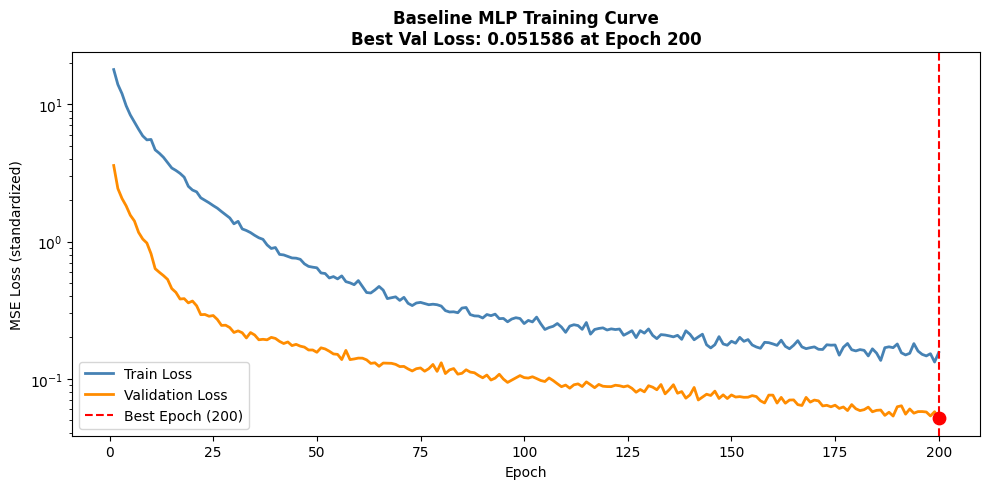

✅ 训练曲线已保存


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

epochs_range = range(1, len(train_losses) + 1)
ax.plot(epochs_range, train_losses, label='Train Loss', 
        color='steelblue', linewidth=2)
ax.plot(epochs_range, val_losses, label='Validation Loss', 
        color='darkorange', linewidth=2)
ax.axvline(best_epoch, color='red', linestyle='--', 
           linewidth=1.5, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_val_loss], color='red', s=80, zorder=5)

ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss (standardized)')
ax.set_title('Baseline MLP Training Curve\n'
             f'Best Val Loss: {best_val_loss:.6f} at Epoch {best_epoch}',
             fontsize=12, fontweight='bold')
ax.legend()
ax.set_yscale('log')    # 对数坐标看得更清楚

plt.tight_layout()
plt.savefig("../docs/fig08_training_curve.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ 训练曲线已保存")

In [13]:
# 加载最优模型
model.load_state_dict(torch.load("../models/baseline_mlp_best.pth", 
                                  map_location=device))
model.eval()

# 收集所有预测结果
all_preds = []
all_true  = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_pred  = model(X_batch).cpu().numpy()
        all_preds.append(y_pred)
        all_true.append(y_batch.numpy())

y_pred_sc = np.vstack(all_preds)
y_true_sc = np.vstack(all_true)

# 反标准化回原始量纲
y_pred_orig = scaler_y.inverse_transform(y_pred_sc)
y_true_orig = scaler_y.inverse_transform(y_true_sc)

# 计算每个输出的 R² 和 MAE
print("=" * 60)
print("测试集最终性能评估")
print("=" * 60)

for i, col in enumerate(output_cols):
    r2  = r2_score(y_true_orig[:, i], y_pred_orig[:, i])
    mae = mean_absolute_error(y_true_orig[:, i], y_pred_orig[:, i])
    mae_pct = mae / np.mean(y_true_orig[:, i]) * 100
    
    print(f"\n{col}:")
    print(f"   R²  = {r2:.6f}  {'✅ 优秀' if r2>0.95 else '⚠️ 需要改进' if r2>0.85 else '❌ 较差'}")
    print(f"   MAE = {mae:.6f}  ({mae_pct:.3f}% 相对误差)")

测试集最终性能评估

Compression_ratio:
   R²  = 0.966380  ✅ 优秀
   MAE = 0.009628  (0.484% 相对误差)

Efficiency:
   R²  = 0.913209  ⚠️ 需要改进
   MAE = 0.002220  (0.255% 相对误差)

Massflow:
   R²  = 0.949184  ⚠️ 需要改进
   MAE = 0.119923  (0.614% 相对误差)


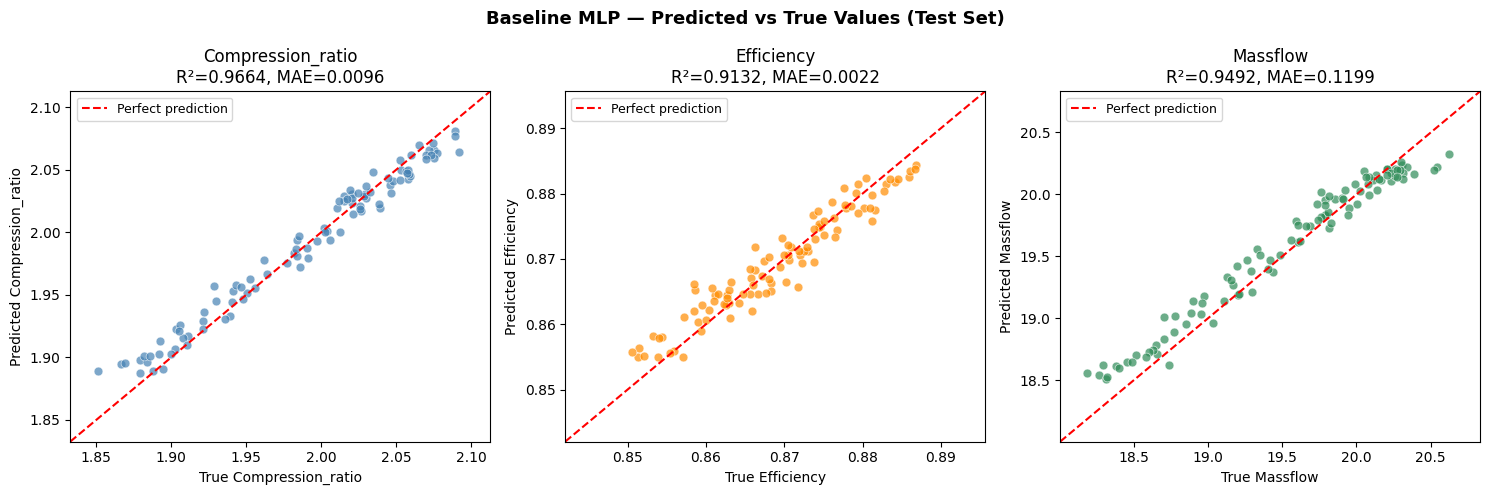

✅ 图9已保存到 docs/


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Baseline MLP — Predicted vs True Values (Test Set)',
             fontsize=13, fontweight='bold')

colors = ['steelblue', 'darkorange', 'seagreen']

for i, (col, color) in enumerate(zip(output_cols, colors)):
    y_true_i = y_true_orig[:, i]
    y_pred_i = y_pred_orig[:, i]
    r2  = r2_score(y_true_i, y_pred_i)
    mae = mean_absolute_error(y_true_i, y_pred_i)
    
    # 散点图
    axes[i].scatter(y_true_i, y_pred_i, 
                    color=color, alpha=0.7, s=40, edgecolors='white', linewidth=0.5)
    
    # 完美预测的对角线（y=x）
    lims = [min(y_true_i.min(), y_pred_i.min()) * 0.99,
            max(y_true_i.max(), y_pred_i.max()) * 1.01]
    axes[i].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    axes[i].set_xlim(lims)
    axes[i].set_ylim(lims)
    
    axes[i].set_xlabel(f'True {col}')
    axes[i].set_ylabel(f'Predicted {col}')
    axes[i].set_title(f'{col}\nR²={r2:.4f}, MAE={mae:.4f}')
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig("../docs/fig09_pred_vs_true_baseline.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ 图9已保存到 docs/")

## 📊 Day 5 基线模型总结

### 模型架构
- 类型：多层感知机（MLP）
- 结构：74 → 256 → 256 → 128 → 64 → 3
- 正则化：Batch Normalization + Dropout(0.2)
- 优化器：Adam (lr=1e-3, weight_decay=1e-4)
- 早停：patience=30 轮

### 数据集划分
- 训练集：800 个样本（80%）
- 验证集：100 个样本（10%）
- 测试集：100 个样本（10%）

### 下一步（Day 6-8）
- 分析基线模型的误差分布
- 加入物理约束（效率上界、压比下界）
- 升级为更深的网络或残差连接（ResNet风格）
- 目标：三个输出的 R² 全部 > 0.95